# Exploratory Data Analysis of Bitcoin Price Prediction Dataset

In this notebook, we perform an in-depth exploration of the Bitcoin price dataset. We focus on data cleaning, visualisation of price trends, and statistical analysis of volatility and autocorrelation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

%matplotlib inline
sns.set(style="whitegrid")

## Load and Inspect Data

We have a historical dataset containing columns: Date, Open, High, Low, Close, Volume, and Market Cap.

In [3]:
train_df = pd.read_csv('../data/bitcoin_price_Training.csv')
print(f"Training dataset entries: {len(train_df)}")
train_df.head()

Training dataset entries: 1556


,Date,Open,High,Low,Close,Volume,Market Cap
0,"Jul 31, 2017",2763.24,2889.62,2720.61,2875.34,"860,575,000","45,535,800,000"
1,"Jul 30, 2017",2724.39,2758.53,2644.85,2757.18,"705,943,000","44,890,700,000"
2,"Jul 29, 2017",2807.02,2808.76,2692.80,2726.45,"803,746,000","46,246,700,000"
3,"Jul 28, 2017",2679.73,2897.45,2679.73,2809.01,"1,380,100,000","44,144,400,000"
4,"Jul 27, 2017",2538.71,2693.32,2529.34,2671.78,"789,104,000","41,816,500,000"


## Preprocessing

We need to parse the dates and handle the string formatting of numeric columns (Volume and Market Cap).

In [4]:
def preprocess_bitcoin_data(df):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    
    for col in ['Volume', 'Market Cap']:
        if df[col].dtype == 'object':
            df[col] = df[col].str.replace(',', '').replace('-', '0').astype(float)
            
    df = df.sort_values('Date').reset_index(drop=True)
    return df

df = preprocess_bitcoin_data(train_df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1556 non-null   datetime64[ns]
 1   Open        1556 non-null   float64       
 2   High        1556 non-null   float64       
 3   Low         1556 non-null   float64       
 4   Close       1556 non-null   float64       
 5   Volume      1556 non-null   float64       
 6   Market Cap  1556 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 85.2 KB


## Exploratory Visualisation

### Price Trends
Bitcoin is known for its exponential growth phases and sharp corrections.

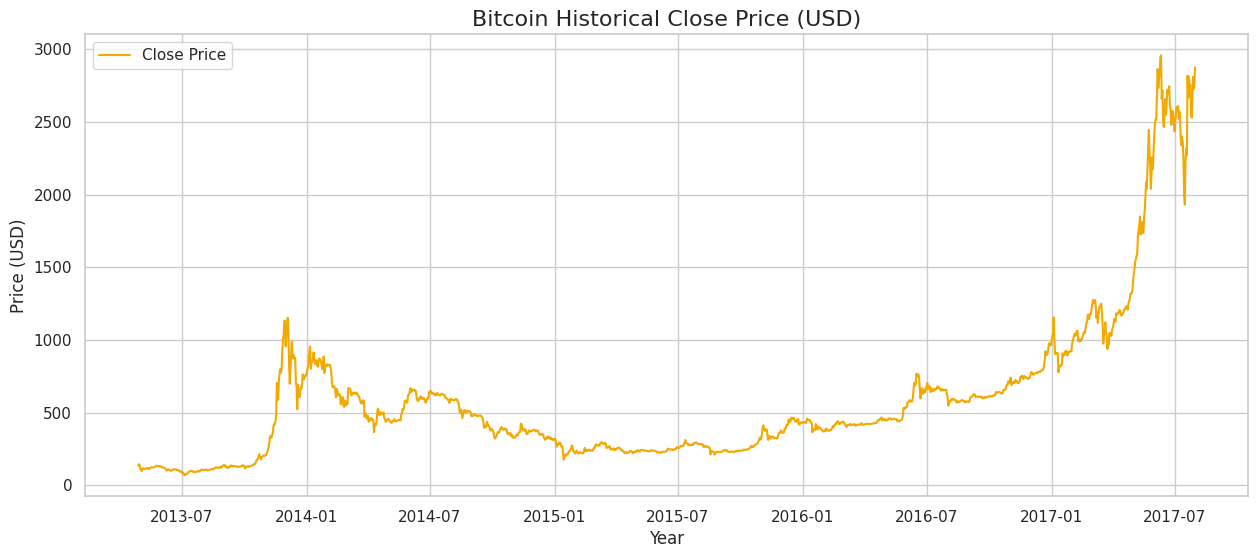

In [5]:
plt.figure(figsize=(15, 6))
plt.plot(df['Date'], df['Close'], label='Close Price', color='#f2a900')
plt.title('Bitcoin Historical Close Price (USD)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

### Moving Averages and Trends
We calculate the 50-day and 200-day moving averages (SMA) to identify macro trends.

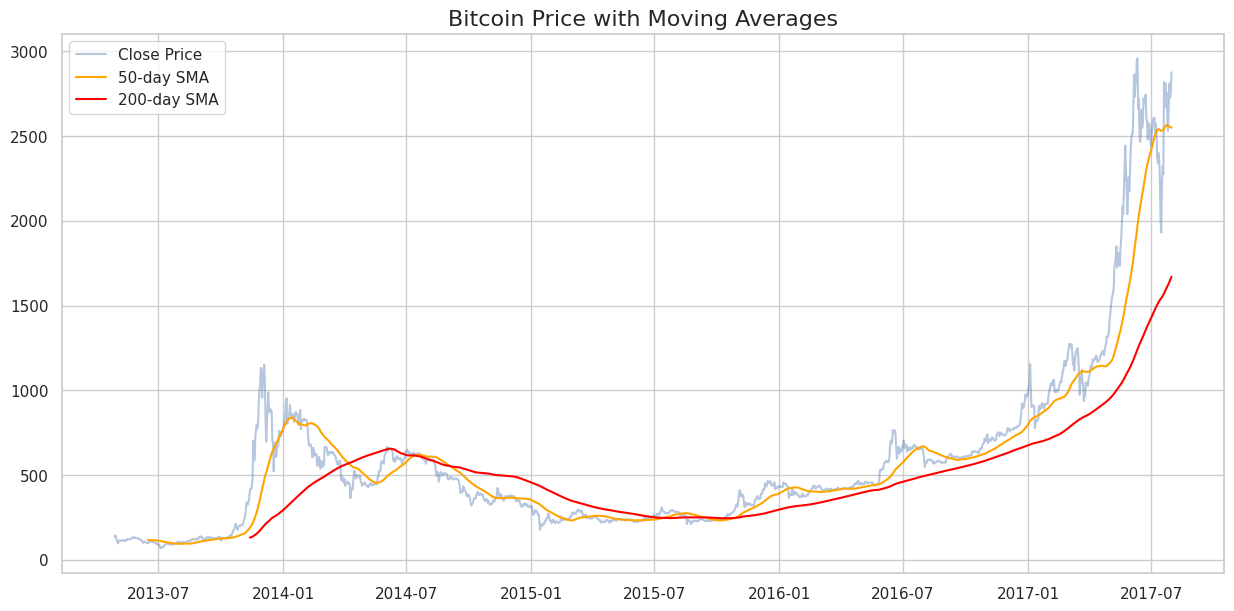

In [6]:
df['SMA50'] = df['Close'].rolling(window=50).mean()
df['SMA200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(15, 7))
plt.plot(df['Date'], df['Close'], label='Close Price', alpha=0.4)
plt.plot(df['Date'], df['SMA50'], label='50-day SMA', color='orange')
plt.plot(df['Date'], df['SMA200'], label='200-day SMA', color='red')
plt.title('Bitcoin Price with Moving Averages', fontsize=16)
plt.legend()
plt.show()

### Daily Returns & Volatility
Financial time series are often analyzed through their returns rather than absolute prices.

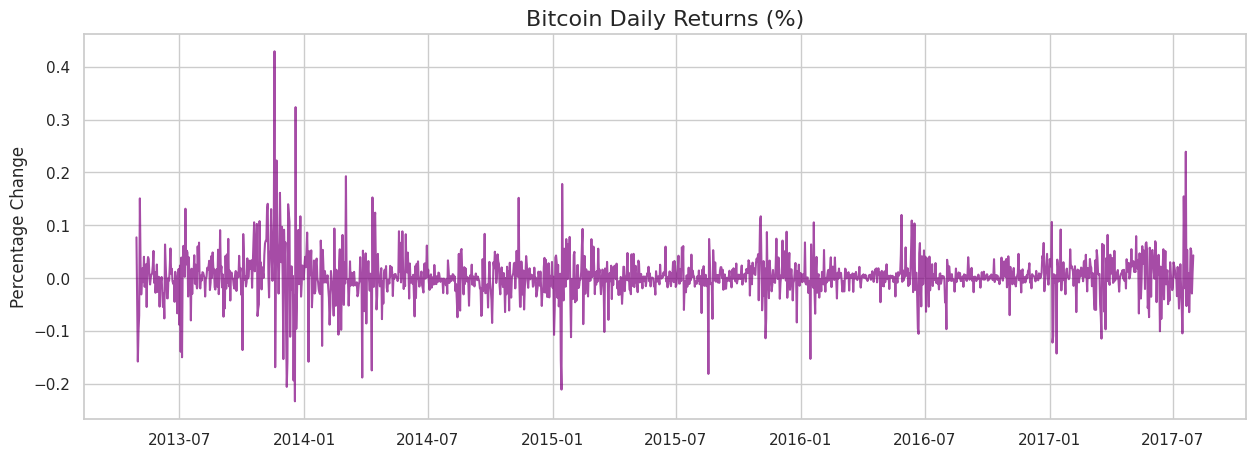

Average Daily Return: 0.2878%
Daily Volatility (Std Dev): 4.2721%


In [7]:
df['Returns'] = df['Close'].pct_change()

plt.figure(figsize=(15, 5))
plt.plot(df['Date'], df['Returns'], color='purple', alpha=0.7)
plt.title('Bitcoin Daily Returns (%)', fontsize=16)
plt.ylabel('Percentage Change')
plt.show()

print(f"Average Daily Return: {df['Returns'].mean()*100:.4f}%")
print(f"Daily Volatility (Std Dev): {df['Returns'].std()*100:.4f}%")

### Distribution of some more features

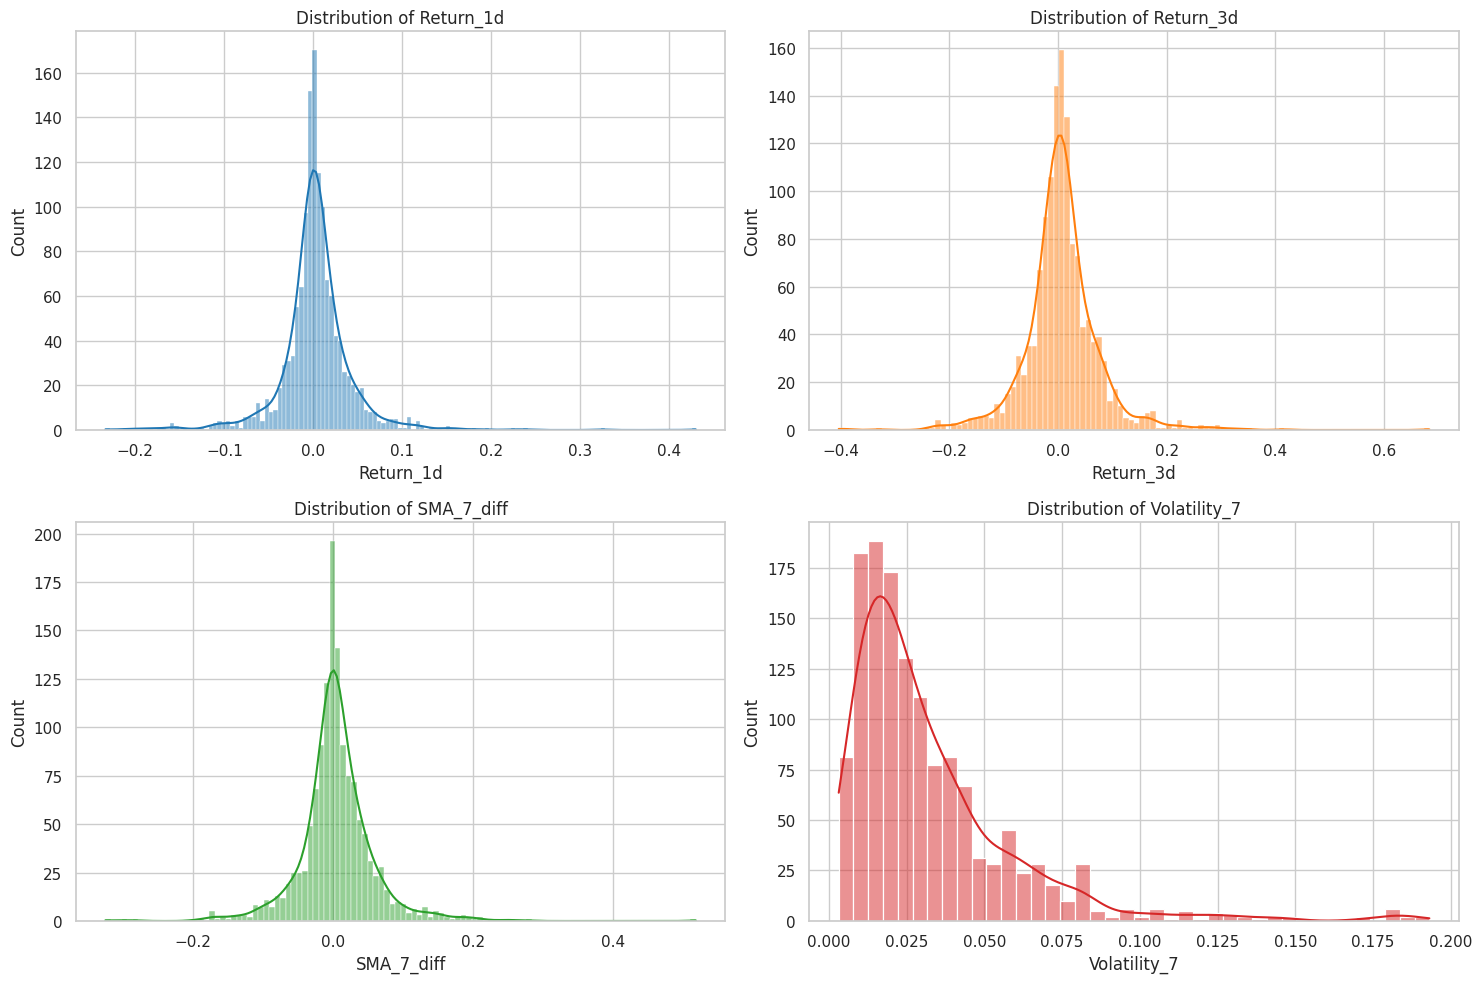

In [11]:
df['Return_1d'] = df['Close'].pct_change()
df['Return_3d'] = df['Close'].pct_change(3)
sma_7 = df['Close'].rolling(window=7).mean()
df['SMA_7_diff'] = (df['Close'] - sma_7) / sma_7
df['Volatility_7'] = df['Return_1d'].rolling(window=7).std()
df['Next_Return'] = df['Return_1d'].shift(-1)
df_features = df.dropna()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
feature_cols = ['Return_1d', 'Return_3d', 'SMA_7_diff', 'Volatility_7']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, col in enumerate(feature_cols):
    sns.histplot(df_features[col], kde=True, ax=axes[i//2, i%2], color=colors[i])
    axes[i//2, i%2].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

## Statistical Tests

### Autocorrelation
We use Autocorrelation Analysis to see if historical prices can likely predict future ones.

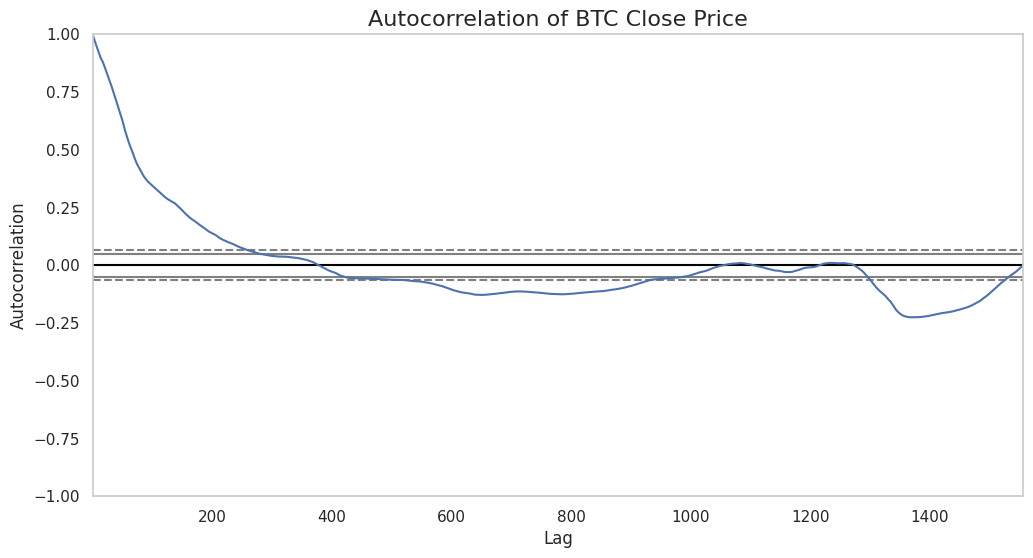

In [8]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(12, 6))
autocorrelation_plot(df['Close'])
plt.title('Autocorrelation of BTC Close Price', fontsize=16)
plt.show()

## Findings

Based on the analysis above, we have finalized our approach and observations:

1. **Growth & Volatility**: Bitcoin shows a mean daily return of **~0.29%**, but with a very high daily volatility (standard deviation) of **~4.27%**. This extreme volatility indicates that price changes are often sharp and non-linear, making simple linear models potentially insufficient.
2. **Trend Persistence**: The Moving Average plots show that price often stays above the 200-day SMA during bull markets and below it during bear markets. Trend-following features like SMA crossovers could be powerful predictors.
3. **Predictive Dependency**: The Autocorrelation plot shows a very high correlation for low lags (Lag-1, Lag-2, etc.) and a slow decay. This statistically confirms that **yesterday's price is a strong predictor for today's price**, justifying the use of Lag Features in our modeling phase.
4. **Modeling Approach**: Due to the high volatility and dependency, we will experiment with various classical and deep learning models.

**Final Decision**: Proceed to model experimentation using a combination of Lag Features, Moving Averages, and Volatility indicators.